In [1]:
%load_ext autoreload
%autoreload 2

import logging
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap

from analyze_sectors_ts import (  # noqa: F401
    collect_points_time_series,
    collect_statistics,
    create_sectors_evolution_mosaic,
    create_time_series_plot,
    find_result_folders,
    load_sector_results,
    plot_area_panel,
    plot_sector_evolution_boxplots,
    plot_swimmer_all_sectors,
    plot_velocity_panel,
    plot_velocity_separation_panel,
)
from ppcluster import load_config, setup_logger

%matplotlib widget

logger = setup_logger(logging.INFO, name="ppcx")

input_dir = Path("output/2020")
output_dir = input_dir / "kinematic_sectors_time_series"

config = load_config()

if not input_dir.exists():
    raise FileNotFoundError(f"Input directory not found: {input_dir}")

output_dir.mkdir(parents=True, exist_ok=True)

UNIT = "px"
UNIT_SCALE = 1.0  # 1 for px, or the m/px conversion factor


dir_pattern = r".*_\d{4}-\d{2}-\d{2}$"
results_pattern = "*results.joblib"

In [2]:
# Find result folders
logger.info(f"Searching for result folders in {input_dir}...")
folders = find_result_folders(input_dir, pattern=dir_pattern)
logger.info(f"Found {len(folders)} result folders")

# Load results from all dates
logger.info("Loading results from all dates...")
results_list = []
for folder in folders:
    result = load_sector_results(folder, search_pattern=results_pattern)
    if result is not None:
        results_list.append(result)

logger.info(f"Successfully loaded {len(results_list)} / {len(folders)} results")

2026-01-29 15:07:39 | [INFO    ] Searching for result folders in output/2020...
2026-01-29 15:07:39 | [INFO    ] Found 152 result folders
2026-01-29 15:07:39 | [INFO    ] Loading results from all dates...
2026-01-29 15:07:39 | [ERROR   ] Failed to load results from output/2020/PPCX_Tele_2020-06-08: No bundle file found in output/2020/PPCX_Tele_2020-06-08
2026-01-29 15:07:39 | [ERROR   ] Failed to load results from output/2020/PPCX_Tele_2020-06-09: No bundle file found in output/2020/PPCX_Tele_2020-06-09
2026-01-29 15:07:39 | [ERROR   ] Failed to load results from output/2020/PPCX_Tele_2020-06-10: No bundle file found in output/2020/PPCX_Tele_2020-06-10
2026-01-29 15:07:39 | [ERROR   ] Failed to load results from output/2020/PPCX_Tele_2020-06-12: No bundle file found in output/2020/PPCX_Tele_2020-06-12
2026-01-29 15:07:39 | [ERROR   ] Failed to load results from output/2020/PPCX_Tele_2020-06-13: No bundle file found in output/2020/PPCX_Tele_2020-06-13
2026-01-29 15:07:39 | [ERROR   ] Fa

In [3]:
def find_data_by_date(results_list, date):
    data = {}
    for res in results_list:
        if res["date"] == date:
            print(f"Found data for date {date}")
            data = res
            break

    return data

In [4]:
date = "2020-08-01"

# Risk matrix is a 3x3 matrix that stores the level of risk for each sector A, B, C (D is not negleted).
# It has two dimensions: Velocity and and the rate of velocity increase compared to one week before (the acceleration).
# The level of risk is represented as an integer from 1 (low risk) to 3 (high risk).

# The level of risk is determined with the following thresholds:

# Velocity thresholds (in px/day):
velocity_thresholds = {
    "A": [10, 13],  # Low: < 10, Medium: 10-13, High: > 13
    "B": [7, 10],  # Low: < 7, Medium: 7-10, High: > 10
    "C": [3, 6],  # Low: < 3, Medium: 3-6, High: >  6
}

# Also the level of risk for each sector is increased if there was a significant identified acceleration (and/or increase of area) in the last week.
days_before_to_check = 7

# Acceleration thresholds (in px/day^2):
# Filling with defaults: 0 (stable/decelerating) and 0.1 (moderate acceleration) as boundaries
default_acc_thresholds = [0.05, 0.2]
acceleration_thresholds = {
    "A": default_acc_thresholds,
    "B": default_acc_thresholds,
    "C": default_acc_thresholds,
}

# Area thresholds (in 10e6 px^2):
# area_thresholds = {
#     "A": [1.7, 2.5],  # Low: <, Medium: -, High: >
#     "B": [],  # Low: <, Medium: -, High: >
#     "C": [],  # Low: <, Medium: -, High: >
# }
# area_thresholds = {k: [v[0] * 1e6, v[1] * 1e6] for k, v in area_thresholds.items()}

# The overall risk level is determined as the maximum risk level among all sectors.
overall_risk_level = 1

# fetch data
date_ts = datetime.strptime(date, "%Y-%m-%d")
date_before = (date_ts - pd.Timedelta(days=days_before_to_check)).strftime("%Y-%m-%d")
data = find_data_by_date(results_list, date)
data_before = find_data_by_date(results_list, date_before)

Found data for date 2020-08-01
Found data for date 2020-07-25


In [5]:
def get_class(value, thresholds):
    """Return 0 (Low), 1 (Medium), or 2 (High) based on thresholds [t1, t2]."""
    if value < thresholds[0]:
        return 0
    elif value <= thresholds[1]:
        return 1
    else:
        return 2


# The risk matrix values is defined as follows:
# x axis: acceleration
# y axis: velocity
risk_matrix_values = np.array(
    [
        [1, 1, 2],  # V=Low:  Acc (Low->1, Med->1, High->2)
        [1, 2, 3],  # V=Med:  Acc (Low->1, Med->2, High->3)
        [3, 3, 3],  # V=High: Acc (Low->3, Med->3, High->3) ~ Conservative approach
    ]
)

# Define colors for risk levels: 1=Green, 2=Yellow, 3=Red
risk_colors = {1: "#2ecc71", 2: "#f1c40f", 3: "#e74c3c"}
risk_labels = {1: "Low", 2: "Medium", 3: "High"}


# Prepare DataFrames
df_curr = data["sectors"].set_index("sector")
if data_before is not None and "sectors" in data_before:
    df_prev = data_before["sectors"].set_index("sector")
else:
    df_prev = pd.DataFrame()

sector_risks = []
for sector in ["A", "B", "C"]:
    if sector not in df_curr.index:
        continue

    # 1. Get Velocity
    v_curr = df_curr.loc[sector, "v_median"]

    # 2. Get Acceleration
    v_prev = np.nan
    acc = 0.0
    if sector in df_prev.index:
        v_prev = df_prev.loc[sector, "v_median"]
        acc = (v_curr - v_prev) / days_before_to_check

    # 3. Determine Classes
    v_thresh = velocity_thresholds[sector]
    a_thresh = acceleration_thresholds[sector]

    v_class = get_class(v_curr, v_thresh)
    a_class = get_class(acc, a_thresh)

    # 4. Determine Combined Risk Level (1, 2, 3)
    risk_level = risk_matrix_values[v_class, a_class]

    sector_risks.append(
        {
            "sector": sector,
            "v_val": v_curr,
            "v_prev": v_prev,
            "a_val": acc,
            "v_class": v_class,
            "a_class": a_class,
            "v_thresh": v_thresh,
            "a_thresh": a_thresh,
            "risk_level": risk_level,
        }
    )


2026-01-29 15:07:40 | [INFO    ] ============================================================
2026-01-29 15:07:40 | [INFO    ] RISK ASSESSMENT DETAILS - 2020-08-01
2026-01-29 15:07:40 | [INFO    ] ============================================================
2026-01-29 15:07:40 | [INFO    ] SECTOR A -> RISK: HIGH
2026-01-29 15:07:40 | [INFO    ]   • Velocity:     13.10 px/d (prev: 8.28)
2026-01-29 15:07:40 | [INFO    ]     Thresholds:   [10, 13] -> Class 2 (0=Low, 1=Med, 2=High)
2026-01-29 15:07:40 | [INFO    ]   • Acceleration: 0.689 px/d² (over 7 days)
2026-01-29 15:07:40 | [INFO    ]     Thresholds:   [0.05, 0.2] -> Class 2
2026-01-29 15:07:40 | [INFO    ] ----------------------------------------
2026-01-29 15:07:40 | [INFO    ] SECTOR B -> RISK: HIGH
2026-01-29 15:07:40 | [INFO    ]   • Velocity:     12.00 px/d (prev: 9.33)
2026-01-29 15:07:40 | [INFO    ]     Thresholds:   [7, 10] -> Class 2 (0=Low, 1=Med, 2=High)
2026-01-29 15:07:40 | [INFO    ]   • Acceleration: 0.382 px/d² (over

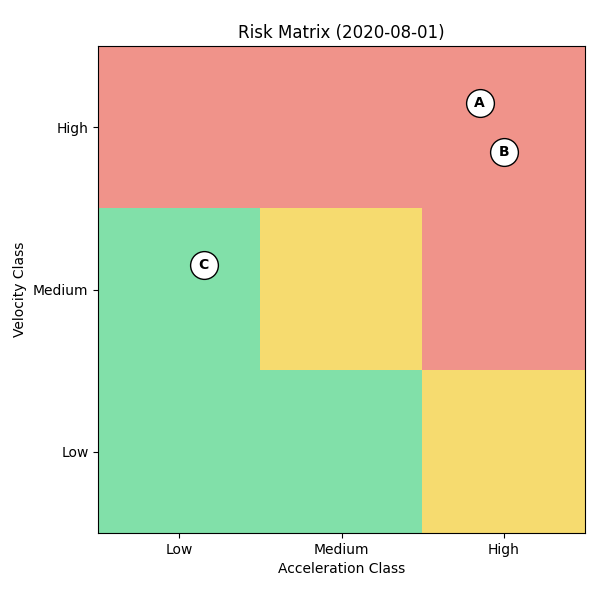

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))

# Plot the background matrix
matrix_display = np.flipud(risk_matrix_values)
cmap_matrix = ListedColormap([risk_colors[1], risk_colors[2], risk_colors[3]])
ax.imshow(
    matrix_display,
    cmap=cmap_matrix,
    vmin=0.5,
    vmax=3.5,
    extent=[-0.5, 2.5, -0.5, 2.5],
    alpha=0.6,
)
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(["Low", "Medium", "High"])
ax.set_yticklabels(["Low", "Medium", "High"])
ax.set_xlabel("Acceleration Class")
ax.set_ylabel("Velocity Class")
ax.set_title(f"Risk Matrix ({date})")

# Plot Sectors
offsets = {"A": (-0.15, 0.15), "B": (0.0, -0.15), "C": (0.15, 0.15), "D": (0.2, -0.2)}

logger.info("=" * 60)
logger.info(f"RISK ASSESSMENT DETAILS - {date}")
logger.info("=" * 60)

for item in sector_risks:
    sec = item["sector"]
    rl = item["risk_level"]
    risk_str = risk_labels[rl].upper()

    # Velocity info
    v_curr = item["v_val"]
    v_prev = item["v_prev"]
    v_cl = item["v_class"]
    v_th = item["v_thresh"]
    v_prev_str = f"{v_prev:.2f}" if not np.isnan(v_prev) else "N/A"

    # Acc info
    acc = item["a_val"]
    a_cl = item["a_class"]
    a_th = item["a_thresh"]

    logger.info(f"SECTOR {sec} -> RISK: {risk_str}")
    logger.info(f"  • Velocity:     {v_curr:.2f} px/d (prev: {v_prev_str})")
    logger.info(f"    Thresholds:   {v_th} -> Class {v_cl} (0=Low, 1=Med, 2=High)")
    logger.info(f"  • Acceleration: {acc:.3f} px/d² (over {days_before_to_check} days)")
    logger.info(f"    Thresholds:   {a_th} -> Class {a_cl}")
    logger.info("-" * 40)

    # Scatter plot
    ox, oy = offsets.get(sec, (0, 0))
    # Note: imshow logic with extent puts 0 at bottom left because of how we set yticks?
    # Actually ax.set_yticklabels(["Low", "Medium", "High"]) matches indices 0,1,2.
    ax.scatter(
        item["a_class"] + ox,
        item["v_class"] + oy,
        s=400,
        edgecolor="black",
        facecolor="white",
        label=f"Sector {sec}",
        zorder=10,
    )
    ax.text(
        item["a_class"] + ox,
        item["v_class"] + oy,
        sec,
        ha="center",
        va="center",
        fontweight="bold",
        zorder=11,
    )

# Overall Risk
max_risk = max([x["risk_level"] for x in sector_risks]) if sector_risks else 1
logger.info(f"OVERALL GLACIER RISK: {max_risk} ({risk_labels[max_risk].upper()})")
logger.info("=" * 60)

plt.tight_layout()
plt.show()
